# Part C Diagnostic: Is Analysis 3 Candidate Scoring Too Flat?

This notebook diagnoses whether the Analysis 3 fulfillment-time proxy produces enough within-order variation across feasible candidate warehouses to support optimization in Part C.

Focus:
- only order lines with more than 1 feasible candidate warehouse,
- only diagnosis of score flatness and dispersion,
- no redesign of the optimization model.

## 1. Load data and helper functions

In [1]:
%matplotlib inline

from pathlib import Path
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

ORDER_LINE_PATH = PROCESSED_DIR / "order_line_with_inventory.csv"
CANDIDATE_PATH = PROCESSED_DIR / "assignment_candidates.csv"

SCORED_CANDIDATE_PATHS = [
    PROCESSED_DIR / "assignment_candidates_scored.csv",
    PROCESSED_DIR / "assignment_candidates_with_predictions.csv",
    PROCESSED_DIR / "candidate_scoring_output.csv",
]

existing_scored_path = next((path for path in SCORED_CANDIDATE_PATHS if path.exists()), None)

order_usecols = [
    "order_line_id",
    "order_date",
    "dc_des",
    "dc_ori",
    "hours_to_delivery",
    "delivered_by_jd_flag",
    "promise_days",
    "promise",
    "quantity",
    "discount_rate",
    "package_count",
    "inventory_at_dc_ori",
    "num_available_dcs_in_region",
    "plus",
    "user_level",
    "purchase_power",
    "city_level",
    "destination_region_id",
    "type",
]

candidate_usecols = [
    "order_line_id",
    "order_id",
    "sku_id",
    "user_id",
    "order_date",
    "dc_des",
    "dc_ori",
    "destination_region_id",
    "candidate_dc",
    "candidate_in_destination_region_flag",
    "candidate_remote_flag",
    "inventory_available",
]

order_line_df = pd.read_csv(ORDER_LINE_PATH, low_memory=False, usecols=lambda c: c in order_usecols)
candidate_df = pd.read_csv(CANDIDATE_PATH, low_memory=False, usecols=lambda c: c in candidate_usecols)
scored_candidate_df = pd.read_csv(existing_scored_path, low_memory=False) if existing_scored_path else None

for frame in [order_line_df, candidate_df]:
    for col in ["order_line_id", "dc_des", "dc_ori", "destination_region_id"]:
        if col in frame.columns:
            frame[col] = frame[col].astype("string")
    if "candidate_dc" in frame.columns:
        frame["candidate_dc"] = frame["candidate_dc"].astype("string")
    if "order_date" in frame.columns:
        frame["order_date"] = pd.to_datetime(frame["order_date"], errors="coerce").dt.normalize()

for col in ["candidate_in_destination_region_flag", "candidate_remote_flag", "inventory_available"]:
    if col in candidate_df.columns:
        candidate_df[col] = pd.to_numeric(candidate_df[col], errors="coerce").fillna(0).astype(int)

print(f"order_line_with_inventory rows: {len(order_line_df):,}")
print(f"assignment_candidates rows: {len(candidate_df):,}")
print(f"existing scored candidate file: {existing_scored_path}")

order_line_with_inventory rows: 549,989
assignment_candidates rows: 3,809,107
existing scored candidate file: None


In [2]:
def stable_holdout_mask(series: pd.Series, train_share: float = 0.8) -> pd.Series:
    hashed = pd.util.hash_pandas_object(series.astype("string"), index=False).astype("uint64")
    return (hashed % 10) < int(train_share * 10)


def make_onehot_encoder():
    params = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in params:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_modeling_sample(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "order_line_id": df["order_line_id"].astype("string"),
            "hours_to_delivery": pd.to_numeric(df.get("hours_to_delivery"), errors="coerce"),
            "remote_fulfillment_flag": (df["dc_ori"].astype("string") != df["dc_des"].astype("string")).astype(float),
            "promise_days": pd.to_numeric(df.get("promise_days", df.get("promise")), errors="coerce"),
            "quantity": pd.to_numeric(df.get("quantity"), errors="coerce"),
            "discount_rate": pd.to_numeric(df.get("discount_rate"), errors="coerce"),
            "package_count": pd.to_numeric(df.get("package_count"), errors="coerce"),
            "inventory_at_fulfillment_dc": pd.to_numeric(df.get("inventory_at_dc_ori"), errors="coerce"),
            "num_available_dcs_in_region": pd.to_numeric(df.get("num_available_dcs_in_region"), errors="coerce"),
            "plus": pd.to_numeric(df.get("plus"), errors="coerce"),
            "user_level": pd.to_numeric(df.get("user_level"), errors="coerce"),
            "purchase_power": pd.to_numeric(df.get("purchase_power"), errors="coerce"),
            "city_level": pd.to_numeric(df.get("city_level"), errors="coerce"),
            "destination_region_id": df.get("destination_region_id").astype("string") if "destination_region_id" in df.columns else pd.Series(pd.NA, index=df.index, dtype="string"),
            "delivered_by_jd_flag": pd.to_numeric(df.get("delivered_by_jd_flag"), errors="coerce") if "delivered_by_jd_flag" in df.columns else 1,
        }
    )

    sku_type_raw = df.get("type")
    if sku_type_raw is None:
        out["sku_type"] = "Unknown"
    else:
        sku_type_num = pd.to_numeric(sku_type_raw, errors="coerce")
        sku_type_text = sku_type_raw.astype("string").fillna("Unknown").str.upper()
        out["sku_type"] = "Unknown"
        out.loc[sku_type_num.eq(1).fillna(False), "sku_type"] = "1P"
        out.loc[sku_type_num.eq(2).fillna(False), "sku_type"] = "3P"
        valid_text_mask = sku_type_text.isin(["1P", "3P"]).fillna(False)
        out.loc[valid_text_mask, "sku_type"] = sku_type_text.loc[valid_text_mask]

    out = out.loc[out["delivered_by_jd_flag"].fillna(1).eq(1)].copy()
    out = out.loc[out["hours_to_delivery"].notna()].copy()
    out = out.loc[out["hours_to_delivery"] > 0].copy()
    out = out.loc[out["hours_to_delivery"] <= 240].copy()

    out["promise_missing_flag"] = out["promise_days"].isna().astype(int)
    out["package_missing_flag"] = out["package_count"].isna().astype(int)
    out["log_hours_to_delivery"] = np.log1p(out["hours_to_delivery"])
    return out.reset_index(drop=True)


def add_business_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["sku_type_3p_flag"] = (out["sku_type"] == "3P").astype(float)
    out["remote_x_inventory_at_fulfillment_dc"] = out["remote_fulfillment_flag"] * out["inventory_at_fulfillment_dc"]
    out["remote_x_package_count"] = out["remote_fulfillment_flag"] * out["package_count"]
    out["remote_x_promise_days"] = out["remote_fulfillment_flag"] * out["promise_days"]
    out["remote_x_sku_type_3p"] = out["remote_fulfillment_flag"] * out["sku_type_3p_flag"]
    return out


def prepare_model_matrix(df: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> pd.DataFrame:
    out = df.copy().replace({pd.NA: np.nan})
    for col in numeric_features:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    for col in categorical_features:
        out[col] = out[col].astype("object")
        out[col] = out[col].where(pd.notna(out[col]), np.nan)
    return out


def fit_analysis3_proxy(order_line_raw: pd.DataFrame):
    model_df = add_business_features(build_modeling_sample(order_line_raw))
    train_mask = stable_holdout_mask(model_df["order_line_id"])

    numeric_features = [
        "remote_fulfillment_flag",
        "promise_days",
        "promise_missing_flag",
        "quantity",
        "discount_rate",
        "package_count",
        "package_missing_flag",
        "inventory_at_fulfillment_dc",
        "num_available_dcs_in_region",
        "plus",
        "user_level",
        "purchase_power",
        "city_level",
        "remote_x_inventory_at_fulfillment_dc",
        "remote_x_package_count",
        "remote_x_promise_days",
        "remote_x_sku_type_3p",
    ]
    categorical_features = ["sku_type", "destination_region_id"]
    feature_columns = numeric_features + categorical_features

    numeric_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    )
    categorical_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_onehot_encoder())]
    )

    preprocessor = ColumnTransformer(
        transformers=[("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)]
    )

    pipeline = Pipeline(
        steps=[("preprocessor", preprocessor), ("ridge", RidgeCV(alphas=np.logspace(-2, 2, 10), cv=5))]
    )

    X_train = prepare_model_matrix(model_df.loc[train_mask, feature_columns].copy(), numeric_features, categorical_features)
    y_train = model_df.loc[train_mask, "log_hours_to_delivery"].copy()
    pipeline.fit(X_train, y_train)
    return model_df, pipeline, feature_columns, numeric_features, categorical_features


def build_candidate_feature_frame(candidate_rows: pd.DataFrame, model_ready_order_line_df: pd.DataFrame) -> pd.DataFrame:
    static_cols = [
        "order_line_id",
        "quantity",
        "discount_rate",
        "promise_days",
        "plus",
        "user_level",
        "purchase_power",
        "city_level",
        "destination_region_id",
        "num_available_dcs_in_region",
        "package_count",
        "sku_type",
    ]
    static_lookup = model_ready_order_line_df[static_cols].drop_duplicates(subset=["order_line_id"]).copy()
    work = candidate_rows.copy().merge(static_lookup, how="left", on="order_line_id", validate="m:1", suffixes=("", "_hist"))

    if "destination_region_id_hist" in work.columns:
        work["destination_region_id"] = work["destination_region_id"].fillna(work["destination_region_id_hist"])

    work["remote_fulfillment_flag"] = pd.to_numeric(work["candidate_remote_flag"], errors="coerce")
    work["inventory_at_fulfillment_dc"] = pd.to_numeric(work["inventory_available"], errors="coerce")
    work["promise_missing_flag"] = pd.to_numeric(work["promise_days"], errors="coerce").isna().astype(int)
    work["package_missing_flag"] = pd.to_numeric(work["package_count"], errors="coerce").isna().astype(int)
    return add_business_features(work)


def ensure_candidate_scores(candidate_rows: pd.DataFrame, order_line_raw: pd.DataFrame, scored_candidates: pd.DataFrame | None = None) -> pd.DataFrame:
    prediction_candidates = ["predicted_hours_to_delivery", "predicted_delivery_hours", "predicted_hours", "t_hat_ij"]
    existing_pred_col = next((col for col in prediction_candidates if col in candidate_rows.columns), None)
    if existing_pred_col is not None:
        scored = candidate_rows.copy()
        if existing_pred_col != "predicted_hours_to_delivery":
            scored = scored.rename(columns={existing_pred_col: "predicted_hours_to_delivery"})
        return scored

    if scored_candidates is not None:
        scored_copy = scored_candidates.copy()
        pred_col = next((col for col in prediction_candidates if col in scored_copy.columns), None)
        if pred_col is not None:
            if pred_col != "predicted_hours_to_delivery":
                scored_copy = scored_copy.rename(columns={pred_col: "predicted_hours_to_delivery"})
            join_cols = [col for col in ["order_line_id", "candidate_dc", "predicted_hours_to_delivery"] if col in scored_copy.columns]
            merged = candidate_rows.merge(
                scored_copy[join_cols].drop_duplicates(subset=["order_line_id", "candidate_dc"]),
                how="left",
                on=["order_line_id", "candidate_dc"],
                validate="m:1",
            )
            if merged["predicted_hours_to_delivery"].notna().all():
                return merged

    model_ready_order_line_df, fitted_pipeline, feature_columns, numeric_features, categorical_features = fit_analysis3_proxy(order_line_raw)
    work = build_candidate_feature_frame(candidate_rows=candidate_rows, model_ready_order_line_df=model_ready_order_line_df)
    work["package_count"] = work["package_count"].fillna(model_ready_order_line_df["package_count"].median())
    model_input = prepare_model_matrix(work[feature_columns].copy(), numeric_features, categorical_features)
    pred_log = fitted_pipeline.predict(model_input)
    work["predicted_hours_to_delivery"] = np.clip(np.expm1(pred_log), a_min=0, a_max=None)
    return work

## 2. Build the diagnostic candidate table

We keep only feasible candidates and only order lines with more than 1 feasible candidate warehouse.

In [3]:
sample_dates = sorted(order_line_df["order_date"].dropna().unique())[:7]
date_filtered_lines = order_line_df.loc[order_line_df["order_date"].isin(sample_dates)].copy()
top_destination_dcs = date_filtered_lines["dc_des"].astype("string").value_counts().head(3).index.tolist()

sample_lines = (
    date_filtered_lines.loc[date_filtered_lines["dc_des"].isin(top_destination_dcs)]
    .sort_values(["order_date", "order_line_id"])
    .drop_duplicates(subset=["order_line_id"])
    .head(1500)
    .copy()
)

if sample_lines.empty:
    sample_lines = order_line_df.sort_values(["order_date", "order_line_id"]).drop_duplicates(subset=["order_line_id"]).head(1500).copy()

scored_candidates = ensure_candidate_scores(candidate_df.copy(), order_line_df, scored_candidate_df)
scored_candidates["predicted_hours_to_delivery"] = pd.to_numeric(scored_candidates["predicted_hours_to_delivery"], errors="coerce")

diag_df = scored_candidates.loc[scored_candidates["order_line_id"].isin(sample_lines["order_line_id"])].copy()
diag_df = diag_df.loc[diag_df["inventory_available"].eq(1)].copy()
diag_df = diag_df.loc[diag_df["predicted_hours_to_delivery"].notna()].copy()

eligible_ids = (
    diag_df.groupby("order_line_id")["candidate_dc"]
    .nunique()
    .loc[lambda s: s > 1]
    .index
)
diag_df = diag_df.loc[diag_df["order_line_id"].isin(eligible_ids)].copy()

print(f"Eligible order lines with >1 feasible candidate: {diag_df['order_line_id'].nunique():,}")
print(f"Feasible candidate rows used in score-flatness diagnostic: {len(diag_df):,}")

Eligible order lines with >1 feasible candidate: 918
Feasible candidate rows used in score-flatness diagnostic: 3,746


## 3. Within-order score dispersion

In [4]:
within_order_dispersion = (
    diag_df.groupby("order_line_id", as_index=False)
    .agg(
        feasible_candidate_count=("candidate_dc", "nunique"),
        min_predicted_hours=("predicted_hours_to_delivery", "min"),
        max_predicted_hours=("predicted_hours_to_delivery", "max"),
        std_predicted_hours=("predicted_hours_to_delivery", "std"),
        local_candidate_count=("candidate_remote_flag", lambda s: int((pd.to_numeric(s, errors="coerce") == 0).sum())),
        remote_candidate_count=("candidate_remote_flag", lambda s: int((pd.to_numeric(s, errors="coerce") == 1).sum())),
    )
)

within_order_dispersion["std_predicted_hours"] = within_order_dispersion["std_predicted_hours"].fillna(0.0)
within_order_dispersion["spread"] = within_order_dispersion["max_predicted_hours"] - within_order_dispersion["min_predicted_hours"]

within_order_dispersion["candidate_count_group"] = np.where(
    within_order_dispersion["feasible_candidate_count"].eq(2),
    "2 feasible candidates",
    "3+ feasible candidates",
)

within_order_dispersion["remote_structure_group"] = np.select(
    [
        (within_order_dispersion["local_candidate_count"] > 0) & (within_order_dispersion["remote_candidate_count"] > 0),
        (within_order_dispersion["local_candidate_count"] > 0) & (within_order_dispersion["remote_candidate_count"] == 0),
        (within_order_dispersion["local_candidate_count"] == 0) & (within_order_dispersion["remote_candidate_count"] > 0),
    ],
    ["mixed local+remote", "local only", "remote only"],
    default="unknown",
)

spread_summary = pd.DataFrame(
    {
        "metric": [
            "eligible_order_lines_multi_feasible",
            "mean_spread_hours",
            "median_spread_hours",
            "mean_std_hours",
            "median_std_hours",
            "share_spread_lt_0_5h",
            "share_spread_lt_1h",
            "share_spread_lt_2h",
            "share_spread_ge_2h",
        ],
        "value": [
            within_order_dispersion["order_line_id"].nunique(),
            within_order_dispersion["spread"].mean(),
            within_order_dispersion["spread"].median(),
            within_order_dispersion["std_predicted_hours"].mean(),
            within_order_dispersion["std_predicted_hours"].median(),
            within_order_dispersion["spread"].lt(0.5).mean(),
            within_order_dispersion["spread"].lt(1.0).mean(),
            within_order_dispersion["spread"].lt(2.0).mean(),
            within_order_dispersion["spread"].ge(2.0).mean(),
        ],
    }
)

display(spread_summary)

,metric,value
0,eligible_order_lines_multi_feasible,918.000000
1,mean_spread_hours,3.187270
2,median_spread_hours,3.179403
3,mean_std_hours,1.677265
4,median_std_hours,1.559969
5,share_spread_lt_0_5h,0.007625
6,share_spread_lt_1h,0.007625
7,share_spread_lt_2h,0.007625
8,share_spread_ge_2h,0.992375


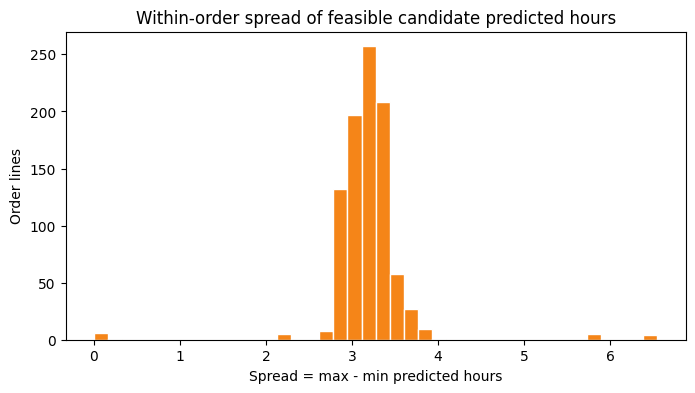

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(within_order_dispersion["spread"], bins=40, color="#f58518", edgecolor="white")
plt.title("Within-order spread of feasible candidate predicted hours")
plt.xlabel("Spread = max - min predicted hours")
plt.ylabel("Order lines")
plt.show()

## 4. Spread by candidate-set structure

In [6]:
count_group_summary = (
    within_order_dispersion.groupby("candidate_count_group", as_index=False)
    .agg(
        order_lines=("order_line_id", "nunique"),
        mean_spread=("spread", "mean"),
        median_spread=("spread", "median"),
        mean_std=("std_predicted_hours", "mean"),
        share_spread_lt_1h=("spread", lambda s: s.lt(1.0).mean()),
        share_spread_lt_2h=("spread", lambda s: s.lt(2.0).mean()),
    )
)

remote_group_summary = (
    within_order_dispersion.groupby("remote_structure_group", as_index=False)
    .agg(
        order_lines=("order_line_id", "nunique"),
        mean_spread=("spread", "mean"),
        median_spread=("spread", "median"),
        mean_std=("std_predicted_hours", "mean"),
        share_spread_lt_1h=("spread", lambda s: s.lt(1.0).mean()),
        share_spread_lt_2h=("spread", lambda s: s.lt(2.0).mean()),
    )
    .sort_values("order_lines", ascending=False)
)

spread_cut_table = pd.DataFrame(
    {
        "spread_cutoff_hours": [0.5, 1.0, 2.0],
        "share_below_cutoff": [
            within_order_dispersion["spread"].lt(0.5).mean(),
            within_order_dispersion["spread"].lt(1.0).mean(),
            within_order_dispersion["spread"].lt(2.0).mean(),
        ],
    }
)

display(count_group_summary)
display(remote_group_summary)
display(spread_cut_table)

,candidate_count_group,order_lines,mean_spread,median_spread,mean_std,share_spread_lt_1h,share_spread_lt_2h
0,2 feasible candidates,204,3.149207,3.124710,2.226826,0.024510,0.024510
1,3+ feasible candidates,714,3.198145,3.205832,1.520247,0.002801,0.002801


,remote_structure_group,order_lines,mean_spread,median_spread,mean_std,share_spread_lt_1h,share_spread_lt_2h
0,mixed local+remote,912,3.208238,3.183386,1.688299,0.001096,0.001096
1,remote only,6,0.000000,0.000000,0.000000,1.000000,1.000000


,spread_cutoff_hours,share_below_cutoff
0,0.5,0.007625
1,1.0,0.007625
2,2.0,0.007625


## 5. Example order lines

In [7]:
low_spread_ids = within_order_dispersion.sort_values(["spread", "feasible_candidate_count"]).head(5)["order_line_id"]
high_spread_ids = within_order_dispersion.sort_values(["spread", "feasible_candidate_count"], ascending=[False, False]).head(5)["order_line_id"]

print("Example order lines with almost identical candidate scores")
display(
    diag_df.loc[diag_df["order_line_id"].isin(low_spread_ids)]
    .sort_values(["order_line_id", "predicted_hours_to_delivery", "candidate_dc"])
    [["order_line_id", "candidate_dc", "dc_des", "dc_ori", "candidate_remote_flag", "predicted_hours_to_delivery"]]
)

print("Example order lines with clearly different candidate scores")
display(
    diag_df.loc[diag_df["order_line_id"].isin(high_spread_ids)]
    .sort_values(["order_line_id", "predicted_hours_to_delivery", "candidate_dc"])
    [["order_line_id", "candidate_dc", "dc_des", "dc_ori", "candidate_remote_flag", "predicted_hours_to_delivery"]]
)

Example order lines with almost identical candidate scores


,order_line_id,candidate_dc,dc_des,dc_ori,candidate_remote_flag,predicted_hours_to_delivery
62839,0450722115_26a569e595_0,19.0,4,4,1,23.493779
62842,0450722115_26a569e595_0,45.0,4,4,1,23.493779
72380,04f24ec5f3_eaa2524751_0,13.0,5,5,1,23.618713
72382,04f24ec5f3_eaa2524751_0,54.0,5,5,1,23.618713
292063,13c29807e0_eaa2524751_0,13.0,5,5,1,23.383795
292065,13c29807e0_eaa2524751_0,54.0,5,5,1,23.383795
299857,144a77beef_12797fae91_0,36.0,9,9,1,25.272567
299860,144a77beef_12797fae91_0,61.0,9,9,1,25.272567
475470,201cc129af_26a569e595_0,19.0,4,4,1,25.282174
475473,201cc129af_26a569e595_0,45.0,4,4,1,25.282174


Example order lines with clearly different candidate scores


,order_line_id,candidate_dc,dc_des,dc_ori,candidate_remote_flag,predicted_hours_to_delivery
2614,002e994572_2523d051fd_0,4.0,4,4,0,51.097387
2618,002e994572_2523d051fd_0,44.0,4,4,1,57.644634
354139,17f2c0e322_c4ea4afceb_0,9.0,9,9,0,50.508064
354140,17f2c0e322_c4ea4afceb_0,25.0,9,9,1,56.981250
354142,17f2c0e322_c4ea4afceb_0,32.0,9,9,1,56.981250
354143,17f2c0e322_c4ea4afceb_0,36.0,9,9,1,56.981250
354144,17f2c0e322_c4ea4afceb_0,50.0,9,9,1,56.981250
354146,17f2c0e322_c4ea4afceb_0,61.0,9,9,1,56.981250
373694,194cc8343f_eb3f2d2fd8_0,5.0,5,5,0,45.581732
373695,194cc8343f_eb3f2d2fd8_0,13.0,5,5,1,51.435809


## 6. Direct interpretation

Use the outputs above to answer the main question directly:

- If most multi-feasible order lines have spread below 0.5h or 1h, the Analysis 3 score is too flat to strongly support reassignment.
- If a large share has spread above 2h, candidate scores vary enough and the main bottleneck is more likely baseline definition or feasible-set structure.
- If only mixed local+remote sets show meaningful spread, that suggests the model mainly distinguishes local vs remote, but not warehouse-to-warehouse differences within the same class.